# Global Air Freight Analysis: Trends, Leaders and Growth Patterns (2005–2019)

**Author:** Muhammad Umer Mehmood

**Education:** Master's In Data Science

---

**Overview of the Dataset Background**

One of the most reliable open data sources in the world, the World Bank's World Development Indicators (WDI), is the source of this dataset. From 2005 to 2019, it monitored air travel activity in 230 countries using four primary metrics: air freight, people carried, carrier departures, and logistics infrastructure quality (LPI score).

**Motivation:**

The core motivation behind analyzing this dataset is to answer real business questions:

Which countries are the biggest players in global air freight? How has air transport grown over 15 years (2005–2019)? Does better logistics infrastructure lead to more freight volume? Which regions are underperforming relative to their potential? How did the pre-COVID era shape the air cargo industry?

**Data Source:** [World Bank Air Transport](https://www.kaggle.com/datasets/tjkyner/global-air-transport-data)

## Import Dataset

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/umercheena/air-cargo-analysis/data.csv", encoding="utf-8-sig")

print(df.shape)
print(df.head())

(1061, 20)
                                         Series Name  Series Code  \
0  Air transport, registered carrier departures w...  IS.AIR.DPRT   
1  Air transport, registered carrier departures w...  IS.AIR.DPRT   
2  Air transport, registered carrier departures w...  IS.AIR.DPRT   
3  Air transport, registered carrier departures w...  IS.AIR.DPRT   
4  Air transport, registered carrier departures w...  IS.AIR.DPRT   

     Country Name Country Code 2005 [YR2005] 2006 [YR2006] 2007 [YR2007]  \
0     Afghanistan          AFG            ..            ..            ..   
1         Albania          ALB          4309          4481          4930   
2         Algeria          DZA         45692         44822         44136   
3  American Samoa          ASM            ..            ..            ..   
4         Andorra          AND            ..            ..            ..   

  2008 [YR2008] 2009 [YR2009]     2010 [YR2010]     2011 [YR2011]  \
0            ..            ..             21677 

In [2]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())

['Series Name', 'Series Code', 'Country Name', 'Country Code', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]']
Series Name      object
Series Code      object
Country Name     object
Country Code     object
2005 [YR2005]    object
2006 [YR2006]    object
2007 [YR2007]    object
2008 [YR2008]    object
2009 [YR2009]    object
2010 [YR2010]    object
2011 [YR2011]    object
2012 [YR2012]    object
2013 [YR2013]    object
2014 [YR2014]    object
2015 [YR2015]    object
2016 [YR2016]    object
2017 [YR2017]    object
2018 [YR2018]    object
2019 [YR2019]    object
2020 [YR2020]    object
dtype: object
Series Name      3
Series Code      5
Country Name     5
Country Code     5
2005 [YR2005]    5
2006 [YR2006]    5
2007 [YR2007]    5
2008 [YR2008]    5
2009 [YR2009]    5


In [3]:
valid_codes = ['IS.AIR.DPRT', 'IS.AIR.GOOD.MT.K1', 'IS.AIR.PSGR', 'LP.LPI.INFR.XQ']
df = df[df['Series Code'].isin(valid_codes)].copy()
print(df.shape)

(1056, 20)


In [4]:
df.rename(columns={
    'Series Name'  : 'series_name',
    'Series Code'  : 'series_code',
    'Country Name' : 'country',
    'Country Code' : 'country_code'
}, inplace=True)

print(df.columns.tolist())

['series_name', 'series_code', 'country', 'country_code', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]']


In [5]:
import numpy as np

year_cols = [c for c in df.columns if 'YR' in c]
df[year_cols] = df[year_cols].replace('..', np.nan)
print(df.isnull().sum())

series_name         0
series_code         0
country             0
country_code        0
2005 [YR2005]     518
2006 [YR2006]     521
2007 [YR2007]     332
2008 [YR2008]     524
2009 [YR2009]     510
2010 [YR2010]     241
2011 [YR2011]     441
2012 [YR2012]     242
2013 [YR2013]     444
2014 [YR2014]     253
2015 [YR2015]     472
2016 [YR2016]     266
2017 [YR2017]     476
2018 [YR2018]     241
2019 [YR2019]     454
2020 [YR2020]    1056
dtype: int64


/tmp/ipykernel_234/2063067642.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[year_cols] = df[year_cols].replace('..', np.nan)


In [6]:
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')
print(df.dtypes)

series_name       object
series_code       object
country           object
country_code      object
2005 [YR2005]    float64
2006 [YR2006]    float64
2007 [YR2007]    float64
2008 [YR2008]    float64
2009 [YR2009]    float64
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
dtype: object


In [7]:
df_long = df.melt(
    id_vars=['country', 'country_code', 'series_name', 'series_code'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)
print(df_long.shape)
print(df_long.head())

(16896, 6)
          country country_code  \
0     Afghanistan          AFG   
1         Albania          ALB   
2         Algeria          DZA   
3  American Samoa          ASM   
4         Andorra          AND   

                                         series_name  series_code  \
0  Air transport, registered carrier departures w...  IS.AIR.DPRT   
1  Air transport, registered carrier departures w...  IS.AIR.DPRT   
2  Air transport, registered carrier departures w...  IS.AIR.DPRT   
3  Air transport, registered carrier departures w...  IS.AIR.DPRT   
4  Air transport, registered carrier departures w...  IS.AIR.DPRT   

            year    value  
0  2005 [YR2005]      NaN  
1  2005 [YR2005]   4309.0  
2  2005 [YR2005]  45692.0  
3  2005 [YR2005]      NaN  
4  2005 [YR2005]      NaN  


In [8]:
df_long['year'] = df_long['year'].str[:4].astype(int)
print(df_long['year'].unique())

[2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019 2020]


In [9]:
df_pivot = df_long.pivot_table(
    index=['country', 'country_code', 'year'],
    columns='series_code',
    values='value'
).reset_index()

print(df_pivot.shape)
print(df_pivot.head())

(3061, 7)
series_code      country country_code  year  IS.AIR.DPRT  IS.AIR.GOOD.MT.K1  \
0            Afghanistan          AFG  2007          NaN                NaN   
1            Afghanistan          AFG  2010      21677.0         108.019487   
2            Afghanistan          AFG  2011      25021.0         109.421117   
3            Afghanistan          AFG  2012      17775.0         116.660723   
4            Afghanistan          AFG  2013      21696.0          84.621216   

series_code   IS.AIR.PSGR  LP.LPI.INFR.XQ  
0                     NaN            1.10  
1            1.999127e+06            1.87  
2            2.279341e+06             NaN  
3            1.737962e+06            2.00  
4            2.044188e+06             NaN  


In [10]:
df_pivot.rename(columns={
    'IS.AIR.DPRT'      : 'departures',
    'IS.AIR.GOOD.MT.K1': 'freight_mton_km',
    'IS.AIR.PSGR'      : 'passengers',
    'LP.LPI.INFR.XQ'   : 'lpi_infra_score'
}, inplace=True)

print(df_pivot.columns.tolist())

['country', 'country_code', 'year', 'departures', 'freight_mton_km', 'passengers', 'lpi_infra_score']


In [11]:
df_pivot.to_csv("air_cargo_clean.csv", index=False)
print("Done! Shape:", df_pivot.shape)

Done! Shape: (3061, 7)


## Exploratory Data Analysis (EDA)

In [12]:
import pandas as pd

df = pd.read_csv("air_cargo_clean.csv")
print(df.shape)
print(df.head())

(3061, 7)
       country country_code  year  departures  freight_mton_km    passengers  \
0  Afghanistan          AFG  2007         NaN              NaN           NaN   
1  Afghanistan          AFG  2010     21677.0       108.019487  1.999127e+06   
2  Afghanistan          AFG  2011     25021.0       109.421117  2.279341e+06   
3  Afghanistan          AFG  2012     17775.0       116.660723  1.737962e+06   
4  Afghanistan          AFG  2013     21696.0        84.621216  2.044188e+06   

   lpi_infra_score  
0             1.10  
1             1.87  
2              NaN  
3             2.00  
4              NaN  


In [13]:
import pandas as pd

df = pd.read_csv("air_cargo_clean.csv")

print(df.shape)
print(df.info())
print(df.describe())

(3061, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3061 entries, 0 to 3060
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          3061 non-null   object 
 1   country_code     3061 non-null   object 
 2   year             3061 non-null   int64  
 3   departures       2921 non-null   float64
 4   freight_mton_km  2851 non-null   float64
 5   passengers       2924 non-null   float64
 6   lpi_infra_score  1209 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 167.5+ KB
None
              year    departures  freight_mton_km    passengers  \
count  3061.000000  2.921000e+03      2851.000000  2.924000e+03   
mean   2012.188174  1.271388e+06      7044.619944  1.263117e+08   
std       4.265595  3.855138e+06     22383.815138  3.847931e+08   
min    2005.000000  0.000000e+00         0.000000  0.000000e+00   
25%    2009.000000  1.187400e+04         3.587026  6.430782e+05   

In [14]:
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

country               0
country_code          0
year                  0
departures          140
freight_mton_km     210
passengers          137
lpi_infra_score    1852
dtype: int64
country             0.000000
country_code        0.000000
year                0.000000
departures          4.573669
freight_mton_km     6.860503
passengers          4.475662
lpi_infra_score    60.503104
dtype: float64


In [15]:
exclude_codes = ['ARB','CSS','CEB','EAR','EAS','TEA','EAP','ECA','TEC','ECS',
                 'EMU','EUU','FCS','HIC','HPC','IBD','IBT','IDB','IDX','IDA',
                 'LTE','LCN','TLA','LAC','LDC','LMY','LIC','LMC','MEA','TMN',
                 'MNA','MIC','NAC','OED','OSS','PSS','PST','PRE','SST','SAS',
                 'TSA','SSF','TSS','SSA','UMC','WLD']

df_countries = df[~df['country_code'].isin(exclude_codes)]

top10 = df_countries.groupby('country')['freight_mton_km'].sum().sort_values(ascending=False).head(10)
print(top10)

country
United States           589293.067256
China                   248312.075200
United Arab Emirates    176458.789467
Korea, Rep.             163760.246413
Hong Kong SAR, China    158051.026451
Japan                   128838.373698
Germany                 117450.996120
Singapore               103392.794273
United Kingdom           90781.142247
Luxembourg               89286.710171
Name: freight_mton_km, dtype: float64


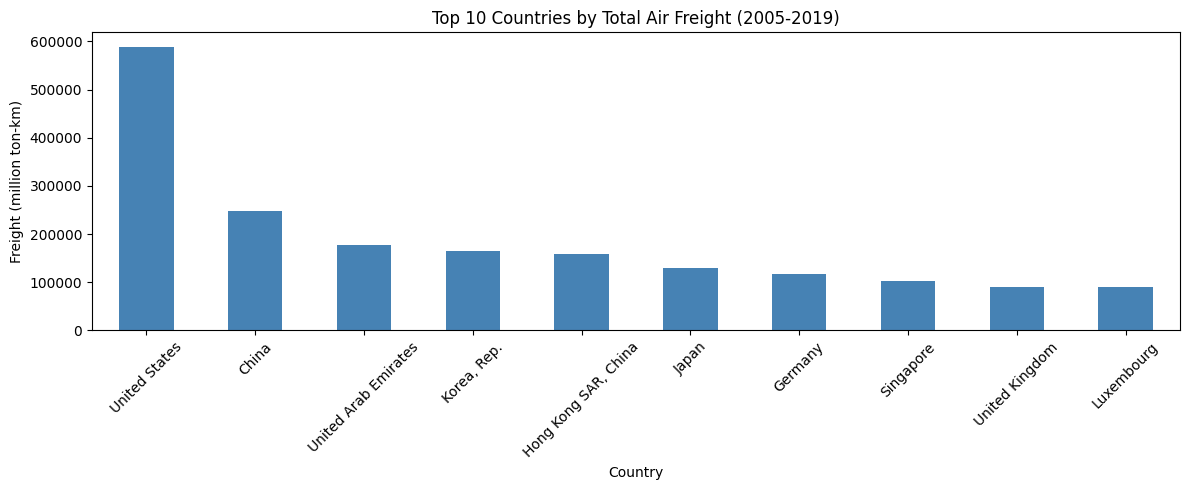

In [16]:
import matplotlib.pyplot as plt

top10.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Top 10 Countries by Total Air Freight (2005-2019)')
plt.xlabel('Country')
plt.ylabel('Freight (million ton-km)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

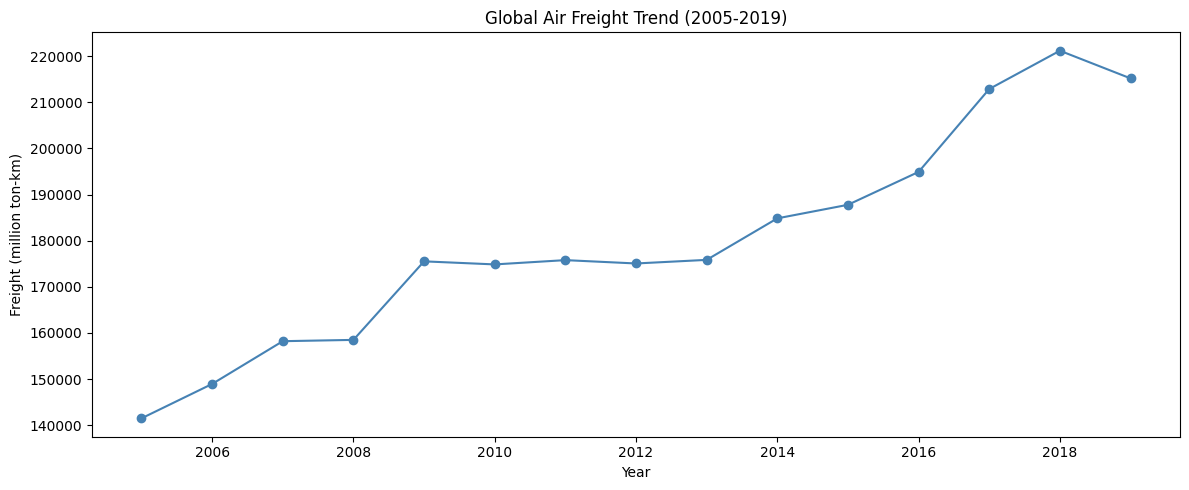

In [17]:
yearly = df_countries.groupby('year')['freight_mton_km'].sum()

yearly.plot(kind='line', figsize=(12, 5), marker='o', color='steelblue')
plt.title('Global Air Freight Trend (2005-2019)')
plt.xlabel('Year')
plt.ylabel('Freight (million ton-km)')
plt.tight_layout()
plt.show()

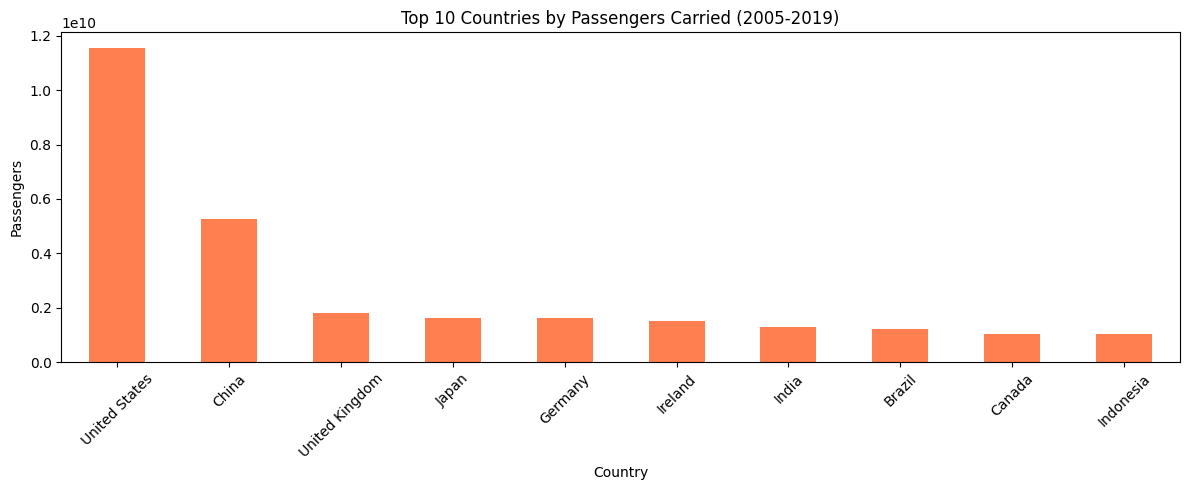

In [18]:
top10_pax = df_countries.groupby('country')['passengers'].sum().sort_values(ascending=False).head(10)

top10_pax.plot(kind='bar', figsize=(12, 5), color='coral')
plt.title('Top 10 Countries by Passengers Carried (2005-2019)')
plt.xlabel('Country')
plt.ylabel('Passengers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

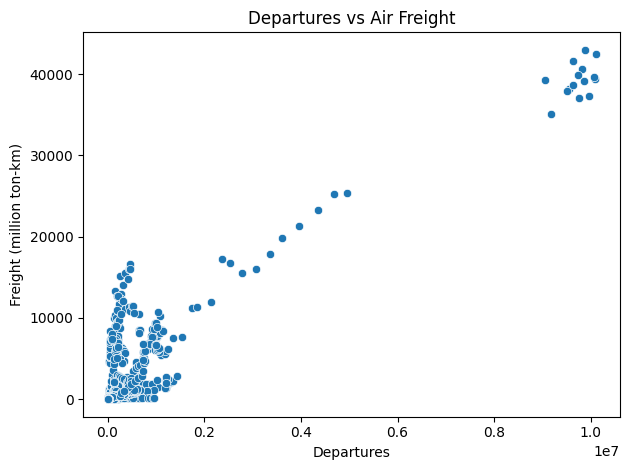

In [19]:
import seaborn as sns

sns.scatterplot(data=df_countries, x='departures', y='freight_mton_km')
plt.title('Departures vs Air Freight')
plt.xlabel('Departures')
plt.ylabel('Freight (million ton-km)')
plt.tight_layout()
plt.show()

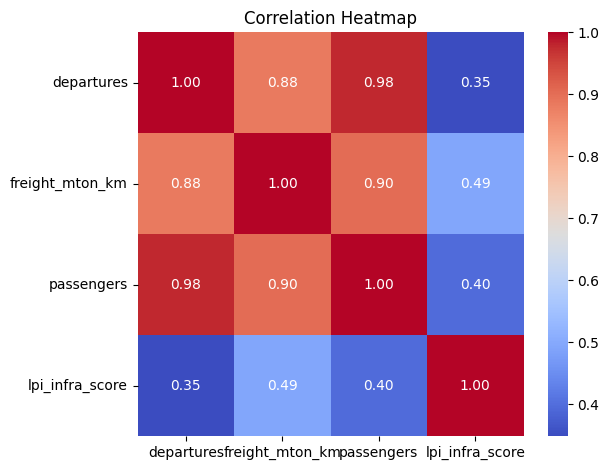

In [20]:
corr = df_countries[['departures', 'freight_mton_km', 'passengers', 'lpi_infra_score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

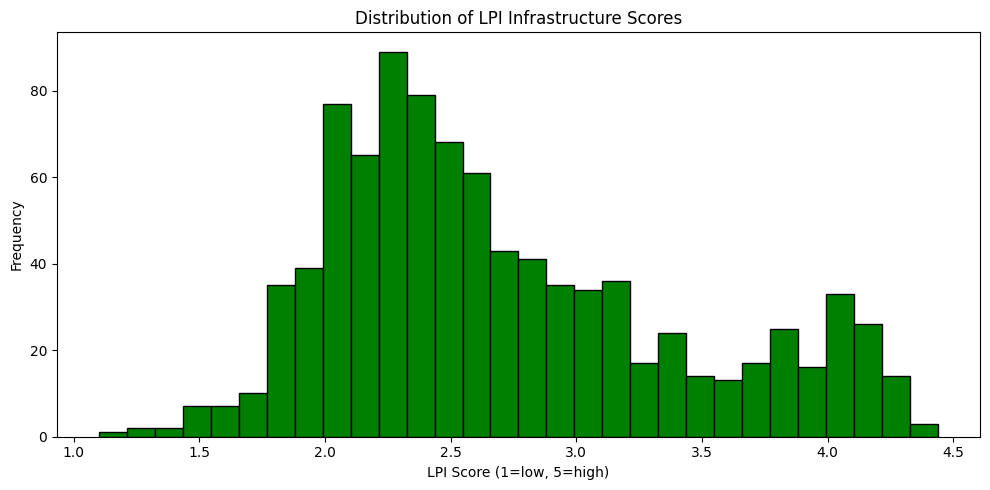

In [21]:
df_countries['lpi_infra_score'].dropna().plot(kind='hist', bins=30, figsize=(10, 5), color='green', edgecolor='black')
plt.title('Distribution of LPI Infrastructure Scores')
plt.xlabel('LPI Score (1=low, 5=high)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

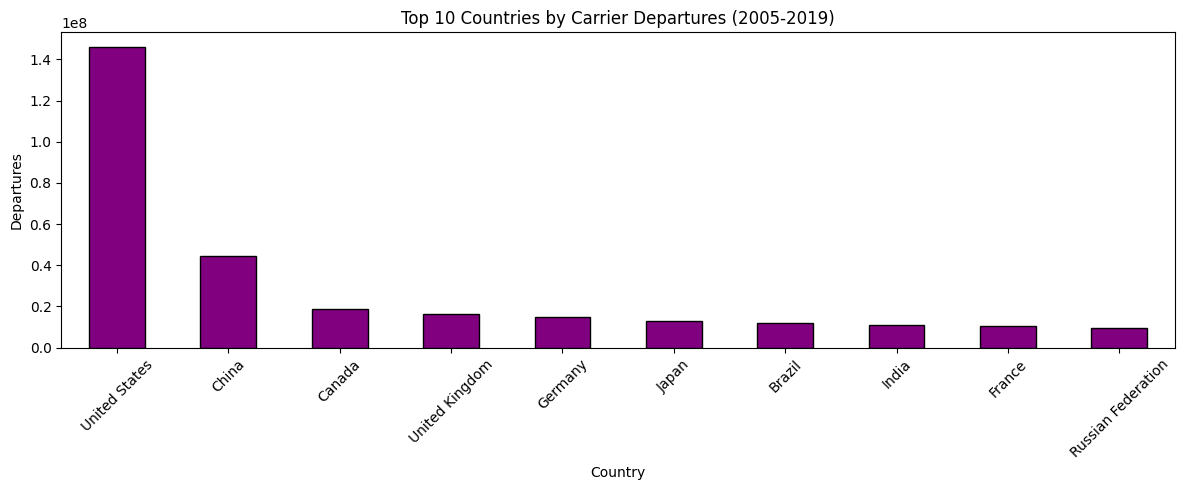

In [22]:
top10_dep = df_countries.groupby('country')['departures'].sum().sort_values(ascending=False).head(10)

top10_dep.plot(kind='bar', figsize=(12, 5), color='purple', edgecolor='black')
plt.title('Top 10 Countries by Carrier Departures (2005-2019)')
plt.xlabel('Country')
plt.ylabel('Departures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
df_countries.to_csv("air_cargo_eda.csv", index=False)
print("Saved! Shape:", df_countries.shape)

Saved! Shape: (2397, 7)


# Feature Engineering

In [24]:
df_countries = df_countries.sort_values(['country', 'year'])

df_countries['freight_yoy_growth'] = df_countries.groupby('country')['freight_mton_km'].pct_change() * 100

print(df_countries[['country', 'year', 'freight_mton_km', 'freight_yoy_growth']].head(20))

        country  year  freight_mton_km  freight_yoy_growth
0   Afghanistan  2007              NaN                 NaN
1   Afghanistan  2010       108.019487                 NaN
2   Afghanistan  2011       109.421117            1.297572
3   Afghanistan  2012       116.660723            6.616279
4   Afghanistan  2013        84.621216          -27.463834
5   Afghanistan  2014        34.283472          -59.485962
6   Afghanistan  2015        33.102039           -3.446073
7   Afghanistan  2016        29.010881          -12.359232
8   Afghanistan  2017        21.462557          -26.018942
9   Afghanistan  2018        29.559349           37.725200
10  Afghanistan  2019        20.014206          -32.291452
21      Albania  2005         0.100000                 NaN
22      Albania  2006         0.105000            5.000000
11      Albania  2007         0.107000            1.904762
23      Albania  2008         0.106000           -0.934579
24      Albania  2009         0.153000           44.3396

/tmp/ipykernel_234/4276920303.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_countries['freight_yoy_growth'] = df_countries.groupby('country')['freight_mton_km'].pct_change() * 100


In [25]:
df_countries['freight_efficiency'] = df_countries['freight_mton_km'] / df_countries['departures']

print(df_countries[['country', 'year', 'freight_mton_km', 'departures', 'freight_efficiency']].head(20))

        country  year  freight_mton_km    departures  freight_efficiency
0   Afghanistan  2007              NaN           NaN                 NaN
1   Afghanistan  2010       108.019487  21677.000000            0.004983
2   Afghanistan  2011       109.421117  25021.000000            0.004373
3   Afghanistan  2012       116.660723  17775.000000            0.006563
4   Afghanistan  2013        84.621216  21696.000000            0.003900
5   Afghanistan  2014        34.283472  25920.000000            0.001323
6   Afghanistan  2015        33.102039  23532.000000            0.001407
7   Afghanistan  2016        29.010881  22770.000000            0.001274
8   Afghanistan  2017        21.462557  24207.000000            0.000887
9   Afghanistan  2018        29.559349  10454.000000            0.002828
10  Afghanistan  2019        20.014206   7334.000000            0.002729
21      Albania  2005         0.100000   4309.000000            0.000023
22      Albania  2006         0.105000   4481.00000

In [26]:
pip install pycountry pycountry-convert

Note: you may need to restart the kernel to use updated packages.


In [27]:
from pycountry_convert import country_alpha2_to_continent_code, country_alpha3_to_country_alpha2
import pycountry

def get_continent(code):
    try:
        alpha2 = country_alpha3_to_country_alpha2(code)
        continent_code = country_alpha2_to_continent_code(alpha2)
        continent_map = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'NA': 'North America',
            'SA': 'South America',
            'OC': 'Oceania',
            'AN': 'Antarctica'
        }
        return continent_map.get(continent_code, 'Unknown')
    except:
        return 'Unknown'

df_countries['continent'] = df_countries['country_code'].apply(get_continent)
print(df_countries[['country', 'country_code', 'continent']].drop_duplicates().head(20))

                 country country_code      continent
0            Afghanistan          AFG           Asia
21               Albania          ALB         Europe
36               Algeria          DZA         Africa
40        American Samoa          ASM        Oceania
56                Angola          AGO         Africa
71   Antigua and Barbuda          ATG  North America
101            Argentina          ARG  South America
114              Armenia          ARM           Asia
118                Aruba          ABW  North America
131            Australia          AUS        Oceania
146              Austria          AUT         Europe
161           Azerbaijan          AZE           Asia
176         Bahamas, The          BHS  North America
180              Bahrain          BHR           Asia
203           Bangladesh          BGD           Asia
218              Belarus          BLR         Europe
233              Belgium          BEL         Europe
237               Belize          BLZ  North A

In [28]:
df_countries['freight_lag1'] = df_countries.groupby('country')['freight_mton_km'].shift(1)
df_countries['freight_lag2'] = df_countries.groupby('country')['freight_mton_km'].shift(2)

print(df_countries[['country', 'year', 'freight_mton_km', 'freight_lag1', 'freight_lag2']].head(20))

        country  year  freight_mton_km  freight_lag1  freight_lag2
0   Afghanistan  2007              NaN           NaN           NaN
1   Afghanistan  2010       108.019487           NaN           NaN
2   Afghanistan  2011       109.421117    108.019487           NaN
3   Afghanistan  2012       116.660723    109.421117    108.019487
4   Afghanistan  2013        84.621216    116.660723    109.421117
5   Afghanistan  2014        34.283472     84.621216    116.660723
6   Afghanistan  2015        33.102039     34.283472     84.621216
7   Afghanistan  2016        29.010881     33.102039     34.283472
8   Afghanistan  2017        21.462557     29.010881     33.102039
9   Afghanistan  2018        29.559349     21.462557     29.010881
10  Afghanistan  2019        20.014206     29.559349     21.462557
21      Albania  2005         0.100000           NaN           NaN
22      Albania  2006         0.105000      0.100000           NaN
11      Albania  2007         0.107000      0.105000      0.10

In [29]:
def calculate_cagr(group):
    first = group[group['year'] == group['year'].min()]['freight_mton_km'].values
    last = group[group['year'] == group['year'].max()]['freight_mton_km'].values
    n = group['year'].max() - group['year'].min()
    if len(first) > 0 and len(last) > 0 and first[0] > 0 and n > 0:
        return ((last[0] / first[0]) ** (1/n) - 1) * 100
    return None

cagr = df_countries.groupby('country').apply(calculate_cagr).reset_index()
cagr.columns = ['country', 'cagr_%']
cagr = cagr.dropna().sort_values('cagr_%', ascending=False)

print(cagr.head(10))

                   country     cagr_%
56                Ethiopia  23.161867
169                 Turkey  22.831921
138                  Qatar  21.136543
49                 Ecuador  17.304170
143  Sao Tome and Principe  17.211298
136                 Poland  11.269246
180                Vietnam  11.241391
140     Russian Federation  10.972940
11              Azerbaijan  10.327254
39             Congo, Rep.   9.287068


/tmp/ipykernel_234/3363870654.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cagr = df_countries.groupby('country').apply(calculate_cagr).reset_index()


In [30]:
df_countries.to_csv("air_cargo_features.csv", index=False)
print("Saved! Shape:", df_countries.shape)
print("Columns:", df_countries.columns.tolist())

Saved! Shape: (2397, 12)
Columns: ['country', 'country_code', 'year', 'departures', 'freight_mton_km', 'passengers', 'lpi_infra_score', 'freight_yoy_growth', 'freight_efficiency', 'continent', 'freight_lag1', 'freight_lag2']


# Modelling

In [31]:
import pandas as pd

df = pd.read_csv("air_cargo_features.csv")
print(df.shape)
print(df.head())

(2397, 12)
       country country_code  year  departures  freight_mton_km    passengers  \
0  Afghanistan          AFG  2007         NaN              NaN           NaN   
1  Afghanistan          AFG  2010     21677.0       108.019487  1.999127e+06   
2  Afghanistan          AFG  2011     25021.0       109.421117  2.279341e+06   
3  Afghanistan          AFG  2012     17775.0       116.660723  1.737962e+06   
4  Afghanistan          AFG  2013     21696.0        84.621216  2.044188e+06   

   lpi_infra_score  freight_yoy_growth  freight_efficiency continent  \
0             1.10                 NaN                 NaN      Asia   
1             1.87                 NaN            0.004983      Asia   
2              NaN            1.297572            0.004373      Asia   
3             2.00            6.616279            0.006563      Asia   
4              NaN          -27.463834            0.003900      Asia   

   freight_lag1  freight_lag2  
0           NaN           NaN  
1          

In [32]:
from sklearn.model_selection import train_test_split

features = ['departures', 'passengers', 'lpi_infra_score', 'freight_lag1', 'freight_lag2', 'freight_efficiency']
target = 'freight_mton_km'

df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (584, 6)
Test size: (147, 6)


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("R2 Score :", round(r2_score(y_test, y_pred_lr), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred_lr), 2))

Linear Regression Results:
R2 Score : 0.9945
MAE      : 174.01


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("R2 Score :", round(r2_score(y_test, y_pred_rf), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred_rf), 2))

Random Forest Results:
R2 Score : 0.9952
MAE      : 139.75


In [35]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [round(r2_score(y_test, y_pred_lr), 4), round(r2_score(y_test, y_pred_rf), 4)],
    'MAE': [round(mean_absolute_error(y_test, y_pred_lr), 2), round(mean_absolute_error(y_test, y_pred_rf), 2)]
})

print(results)

               Model  R2 Score     MAE
0  Linear Regression    0.9945  174.01
1      Random Forest    0.9952  139.75


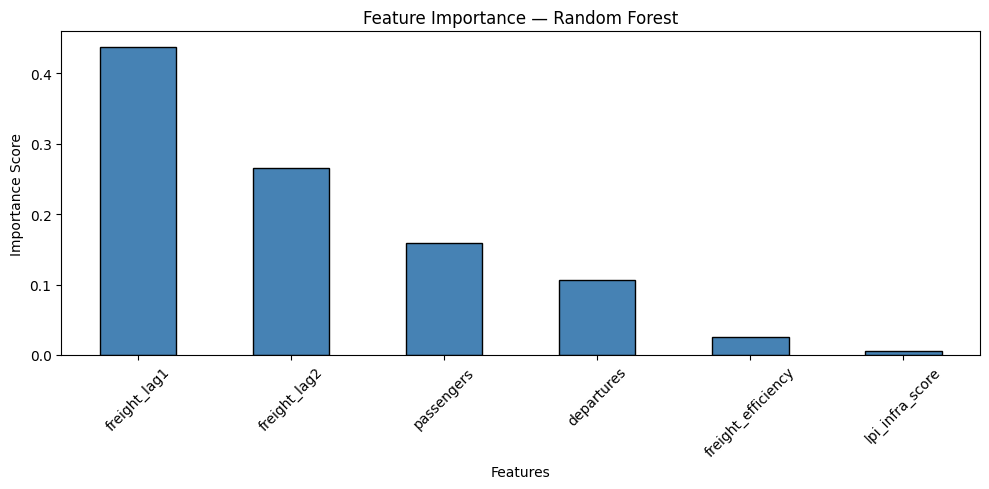

In [36]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

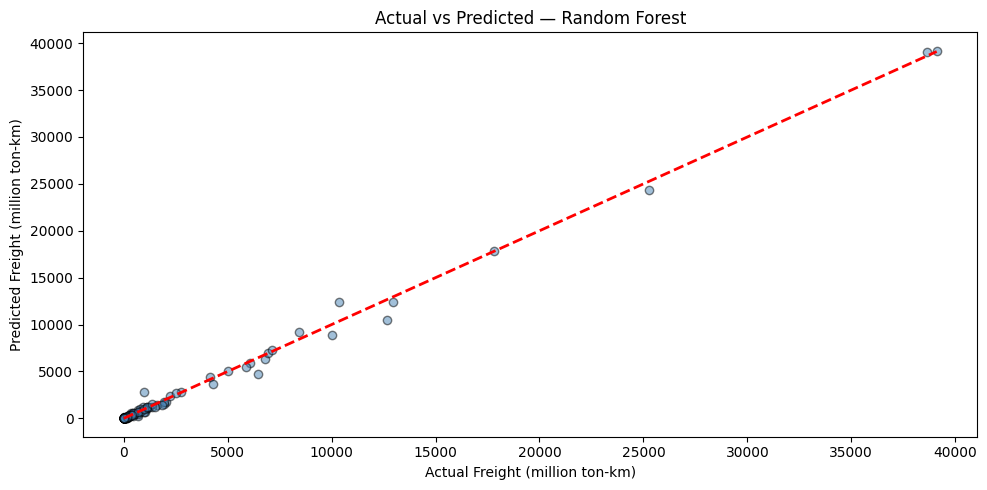

In [37]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_rf, color='steelblue', alpha=0.5, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted — Random Forest')
plt.xlabel('Actual Freight (million ton-km)')
plt.ylabel('Predicted Freight (million ton-km)')
plt.tight_layout()
plt.show()

In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ['departures', 'freight_mton_km', 'passengers', 'lpi_infra_score']
df_cluster = df[cluster_features + ['country']].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

print(df_cluster.groupby('cluster')[cluster_features].mean().round(2))

         departures  freight_mton_km    passengers  lpi_infra_score
cluster                                                            
0         698171.31          8158.00  7.979842e+07             3.97
1          40085.46           115.36  3.513363e+06             2.30
2        8437073.88         35688.94  7.220840e+08             4.03
3         232297.07           825.56  2.539998e+07             3.30


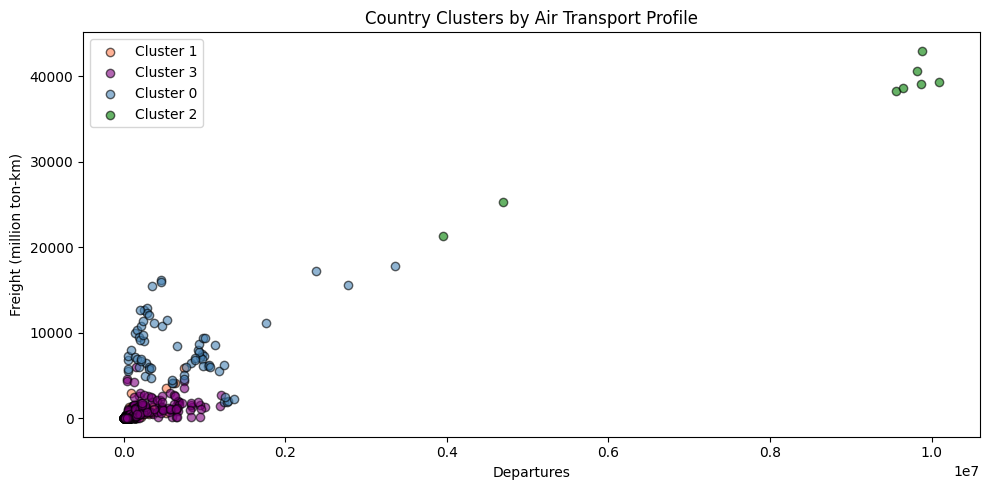

In [39]:
plt.figure(figsize=(10, 5))
colors_map = {0: 'steelblue', 1: 'coral', 2: 'green', 3: 'purple'}

for cluster in df_cluster['cluster'].unique():
    subset = df_cluster[df_cluster['cluster'] == cluster]
    plt.scatter(subset['departures'], subset['freight_mton_km'],
                label=f'Cluster {cluster}',
                color=colors_map[cluster],
                alpha=0.6, edgecolor='black')

plt.title('Country Clusters by Air Transport Profile')
plt.xlabel('Departures')
plt.ylabel('Freight (million ton-km)')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
df_cluster.to_csv("air_cargo_model.csv", index=False)
print("Saved! Shape:", df_cluster.shape)
print("Columns:", df_cluster.columns.tolist())

Saved! Shape: (782, 6)
Columns: ['departures', 'freight_mton_km', 'passengers', 'lpi_infra_score', 'country', 'cluster']


# Dashboard

In [41]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [49]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/umercheena/air-cargo-analysis/data.csv


In [50]:
df = pd.read_csv("/kaggle/input/datasets/umercheena/air-cargo-analysis/data.csv", encoding="utf-8-sig")
print(df.shape)

(1061, 20)


In [51]:
import pandas as pd
import numpy as np

# Load
df = pd.read_csv("/kaggle/input/datasets/umercheena/air-cargo-analysis/data.csv", encoding="utf-8-sig")

# Filter 4 series
valid_codes = ['IS.AIR.DPRT', 'IS.AIR.GOOD.MT.K1', 'IS.AIR.PSGR', 'LP.LPI.INFR.XQ']
df = df[df['Series Code'].isin(valid_codes)].copy()

# Rename columns
df.rename(columns={
    'Series Name'  : 'series_name',
    'Series Code'  : 'series_code',
    'Country Name' : 'country',
    'Country Code' : 'country_code'
}, inplace=True)

# Fix year columns
year_cols = [c for c in df.columns if 'YR' in c]
df[year_cols] = df[year_cols].replace('..', np.nan)
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')

# Melt
df_long = df.melt(
    id_vars=['country', 'country_code', 'series_name', 'series_code'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)
df_long['year'] = df_long['year'].str[:4].astype(int)

# Pivot
df_pivot = df_long.pivot_table(
    index=['country', 'country_code', 'year'],
    columns='series_code',
    values='value'
).reset_index()
df_pivot.columns.name = None

# Rename metrics
df_pivot.rename(columns={
    'IS.AIR.DPRT'      : 'departures',
    'IS.AIR.GOOD.MT.K1': 'freight_mton_km',
    'IS.AIR.PSGR'      : 'passengers',
    'LP.LPI.INFR.XQ'   : 'lpi_infra_score'
}, inplace=True)

print("Done! Shape:", df_pivot.shape)
print(df_pivot.head())

Done! Shape: (3061, 7)
       country country_code  year  departures  freight_mton_km    passengers  \
0  Afghanistan          AFG  2007         NaN              NaN           NaN   
1  Afghanistan          AFG  2010     21677.0       108.019487  1.999127e+06   
2  Afghanistan          AFG  2011     25021.0       109.421117  2.279341e+06   
3  Afghanistan          AFG  2012     17775.0       116.660723  1.737962e+06   
4  Afghanistan          AFG  2013     21696.0        84.621216  2.044188e+06   

   lpi_infra_score  
0             1.10  
1             1.87  
2              NaN  
3             2.00  
4              NaN  


/tmp/ipykernel_234/2680401092.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[year_cols] = df[year_cols].replace('..', np.nan)


In [52]:
import pandas as pd
import numpy as np

# Load
df = pd.read_csv("/kaggle/input/datasets/umercheena/air-cargo-analysis/data.csv", encoding="utf-8-sig")

# Filter 4 series
valid_codes = ['IS.AIR.DPRT', 'IS.AIR.GOOD.MT.K1', 'IS.AIR.PSGR', 'LP.LPI.INFR.XQ']
df = df[df['Series Code'].isin(valid_codes)].copy()

# Rename columns
df.rename(columns={
    'Series Name'  : 'series_name',
    'Series Code'  : 'series_code',
    'Country Name' : 'country',
    'Country Code' : 'country_code'
}, inplace=True)

# Fix year columns
year_cols = [c for c in df.columns if 'YR' in c]
df[year_cols] = df[year_cols].replace('..', np.nan)
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')

# Melt
df_long = df.melt(
    id_vars=['country', 'country_code', 'series_name', 'series_code'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)
df_long['year'] = df_long['year'].str[:4].astype(int)

# Pivot
df_pivot = df_long.pivot_table(
    index=['country', 'country_code', 'year'],
    columns='series_code',
    values='value'
).reset_index()
df_pivot.columns.name = None

# Rename metrics
df_pivot.rename(columns={
    'IS.AIR.DPRT'      : 'departures',
    'IS.AIR.GOOD.MT.K1': 'freight_mton_km',
    'IS.AIR.PSGR'      : 'passengers',
    'LP.LPI.INFR.XQ'   : 'lpi_infra_score'
}, inplace=True)

print("Done! Shape:", df_pivot.shape)
print(df_pivot.head())

Done! Shape: (3061, 7)
       country country_code  year  departures  freight_mton_km    passengers  \
0  Afghanistan          AFG  2007         NaN              NaN           NaN   
1  Afghanistan          AFG  2010     21677.0       108.019487  1.999127e+06   
2  Afghanistan          AFG  2011     25021.0       109.421117  2.279341e+06   
3  Afghanistan          AFG  2012     17775.0       116.660723  1.737962e+06   
4  Afghanistan          AFG  2013     21696.0        84.621216  2.044188e+06   

   lpi_infra_score  
0             1.10  
1             1.87  
2              NaN  
3             2.00  
4              NaN  


/tmp/ipykernel_234/2680401092.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[year_cols] = df[year_cols].replace('..', np.nan)


In [53]:
# Sort by country and year
df_countries = df_countries.sort_values(['country', 'year'])

# YoY growth rate
df_countries['freight_yoy_growth'] = df_countries.groupby('country')['freight_mton_km'].pct_change() * 100

# Freight efficiency ratio
df_countries['freight_efficiency'] = df_countries['freight_mton_km'] / df_countries['departures']

# Lag features
df_countries['freight_lag1'] = df_countries.groupby('country')['freight_mton_km'].shift(1)
df_countries['freight_lag2'] = df_countries.groupby('country')['freight_mton_km'].shift(2)

# CAGR per country
def calculate_cagr(group):
    first = group[group['year'] == group['year'].min()]['freight_mton_km'].values
    last  = group[group['year'] == group['year'].max()]['freight_mton_km'].values
    n     = group['year'].max() - group['year'].min()
    if len(first) > 0 and len(last) > 0 and first[0] > 0 and n > 0:
        return ((last[0] / first[0]) ** (1/n) - 1) * 100
    return None

cagr = df_countries.groupby('country').apply(calculate_cagr).reset_index()
cagr.columns = ['country', 'cagr_%']

print("Feature Engineering Complete!")
print(df_countries.columns.tolist())
print(df_countries.head())

Feature Engineering Complete!
['country', 'country_code', 'year', 'departures', 'freight_mton_km', 'passengers', 'lpi_infra_score', 'freight_yoy_growth', 'freight_efficiency', 'continent', 'freight_lag1', 'freight_lag2']
       country country_code  year  departures  freight_mton_km    passengers  \
0  Afghanistan          AFG  2007         NaN              NaN           NaN   
1  Afghanistan          AFG  2010     21677.0       108.019487  1.999127e+06   
2  Afghanistan          AFG  2011     25021.0       109.421117  2.279341e+06   
3  Afghanistan          AFG  2012     17775.0       116.660723  1.737962e+06   
4  Afghanistan          AFG  2013     21696.0        84.621216  2.044188e+06   

   lpi_infra_score  freight_yoy_growth  freight_efficiency continent  \
0             1.10                 NaN                 NaN      Asia   
1             1.87                 NaN            0.004983      Asia   
2              NaN            1.297572            0.004373      Asia   
3         

/tmp/ipykernel_234/2287351830.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_countries['freight_yoy_growth'] = df_countries.groupby('country')['freight_mton_km'].pct_change() * 100
/tmp/ipykernel_234/2287351830.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cagr = df_countries.groupby('country').apply(calculate_cagr).reset_index()


               Model  R2 Score     MAE
0  Linear Regression    0.9945  174.01
1      Random Forest    0.9952  139.75


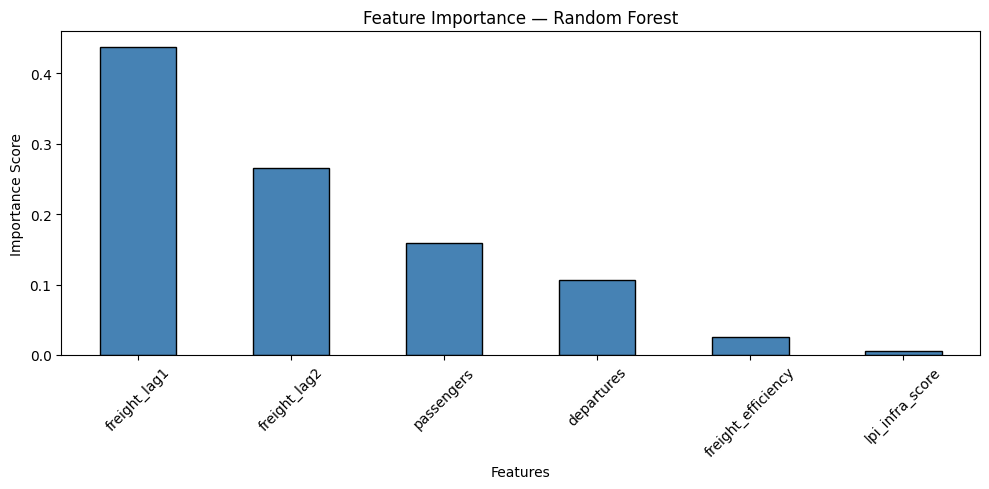

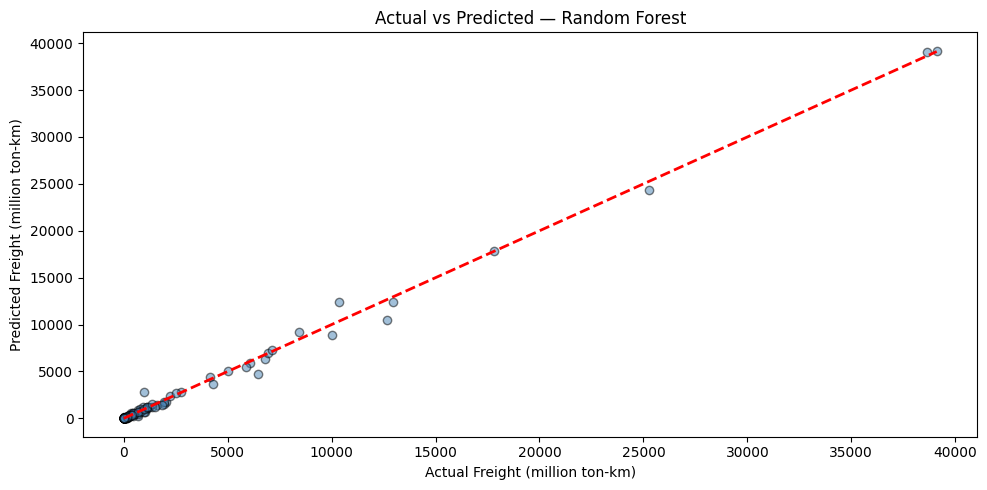

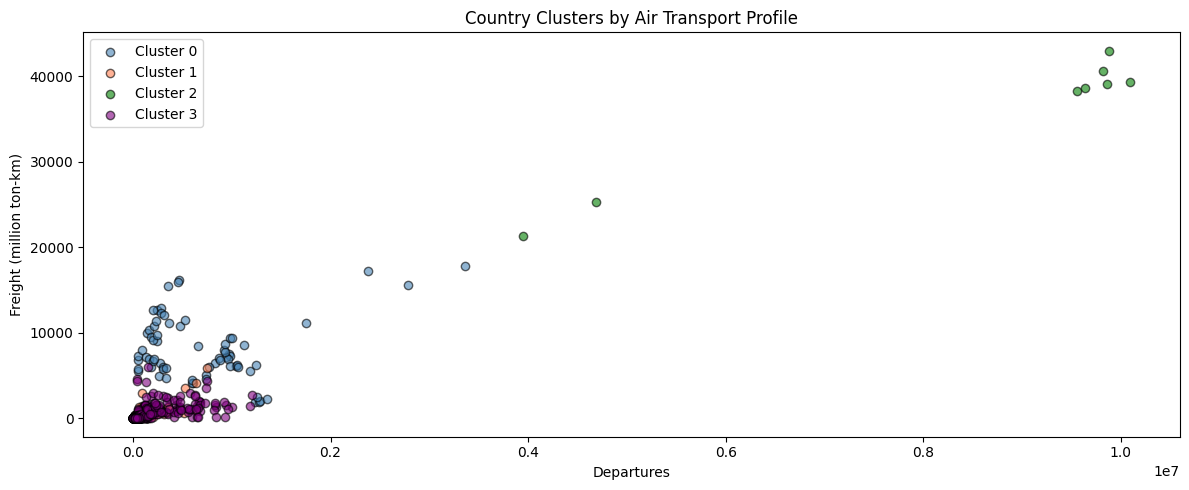

Modelling Complete!
         departures  freight_mton_km    passengers  lpi_infra_score
cluster                                                            
0         698171.31          8158.00  7.979842e+07             3.97
1          40085.46           115.36  3.513363e+06             2.30
2        8437073.88         35688.94  7.220840e+08             4.03
3         232297.07           825.56  2.539998e+07             3.30


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── Prepare data ──────────────────────────
features = ['departures','passengers','lpi_infra_score','freight_lag1','freight_lag2','freight_efficiency']
target   = 'freight_mton_km'

df_model = df_countries[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Linear Regression ─────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# ── Random Forest ─────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ── Model Comparison ──────────────────────
results = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'R2 Score': [round(r2_score(y_test, y_pred_lr), 4), round(r2_score(y_test, y_pred_rf), 4)],
    'MAE'     : [round(mean_absolute_error(y_test, y_pred_lr), 2), round(mean_absolute_error(y_test, y_pred_rf), 2)]
})
print(results)

# ── Feature Importance ────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(10,5), color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Actual vs Predicted ───────────────────
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_rf, color='steelblue', alpha=0.5, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted — Random Forest')
plt.xlabel('Actual Freight (million ton-km)')
plt.ylabel('Predicted Freight (million ton-km)')
plt.tight_layout()
plt.show()

# ── K-Means Clustering ────────────────────
cluster_features = ['departures','freight_mton_km','passengers','lpi_infra_score']
df_cluster = df_countries[cluster_features + ['country']].dropna()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

colors_list = ['steelblue','coral','green','purple']
plt.figure(figsize=(12,5))
for cluster in sorted(df_cluster['cluster'].unique()):
    subset = df_cluster[df_cluster['cluster'] == cluster]
    plt.scatter(subset['departures'], subset['freight_mton_km'],
                label=f'Cluster {cluster}',
                color=colors_list[cluster], alpha=0.6, edgecolor='black')
plt.title('Country Clusters by Air Transport Profile')
plt.xlabel('Departures')
plt.ylabel('Freight (million ton-km)')
plt.legend()
plt.tight_layout()
plt.show()

print("Modelling Complete!")
print(df_cluster.groupby('cluster')[cluster_features].mean().round(2))

In [55]:
# Save all datasets
df_pivot.to_csv('air_cargo_clean.csv', index=False)
df_countries.to_csv('air_cargo_eda.csv', index=False)
df_cluster.to_csv('air_cargo_model.csv', index=False)
cagr.to_csv('air_cargo_cagr.csv', index=False)

print("All files saved!")
print("air_cargo_clean.csv   :", df_pivot.shape)
print("air_cargo_eda.csv     :", df_countries.shape)
print("air_cargo_model.csv   :", df_cluster.shape)
print("air_cargo_cagr.csv    :", cagr.shape)

All files saved!
air_cargo_clean.csv   : (3061, 7)
air_cargo_eda.csv     : (2397, 12)
air_cargo_model.csv   : (782, 6)
air_cargo_cagr.csv    : (184, 2)
